# Inspecting the pipeline of the VAE 

This will look at the VAE step by step

## Step 1: Inspecting the created datasets

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
import sys
from pathlib import Path

In [24]:
train_discovery = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/train_discovery.npy')
# train_discovery_pheno = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/train_discovery_pheno.npy')
train_target = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/train_target.npy')
# train_target_pheno = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/train_target_pheno.npy')
validation_discovery = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/validation_discovery.npy')
# validation_pheno = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/validation_discovery_pheno.npy')
test_target = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/test_target.npy')
# test_target_pheno = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/test_target_pheno.npy')


# FOR NOW, LOAD IN THE SANITY CHECK PHENOTYPES
train_discovery_pheno = np.load('/sietch_colab/akapoor/XPopVAE/phenotype_creation/simulated_phenotype_train_discovery.npy')
train_target_pheno = np.load('/sietch_colab/akapoor/XPopVAE/phenotype_creation/simulated_phenotype_train_target.npy')
test_target_pheno = np.load('/sietch_colab/akapoor/XPopVAE/experiments/IM_symmetric/processed_data/0/rep0/test_target_pheno.npy')
validation_pheno = np.load('/sietch_colab/akapoor/XPopVAE/phenotype_creation/simulated_phenotype_val_discovery.npy')

In [29]:
print(f'Train Discovery Shape: {train_discovery.shape}')
print(f'Train Phenotype Shape: {train_discovery_pheno.shape}')
print(f'Train Target Shape: {train_target.shape}')
print(f'Train Target Phenotype Shape: {train_target_pheno.shape}')
print(f'Test Target Shape: {test_target.shape}')
print(f'Test Target Phenotype Shape: {test_target_pheno.shape}')
print(f'Validation Shape: {validation_discovery.shape}')
print(f'Validation Phenotype Shape: {validation_pheno.shape}')

Train Discovery Shape: (800, 9013)
Train Phenotype Shape: (800,)
Train Target Shape: (800, 9013)
Train Target Phenotype Shape: (800,)
Test Target Shape: (200, 9013)
Test Target Phenotype Shape: (200,)
Validation Shape: (200, 9013)
Validation Phenotype Shape: (200,)


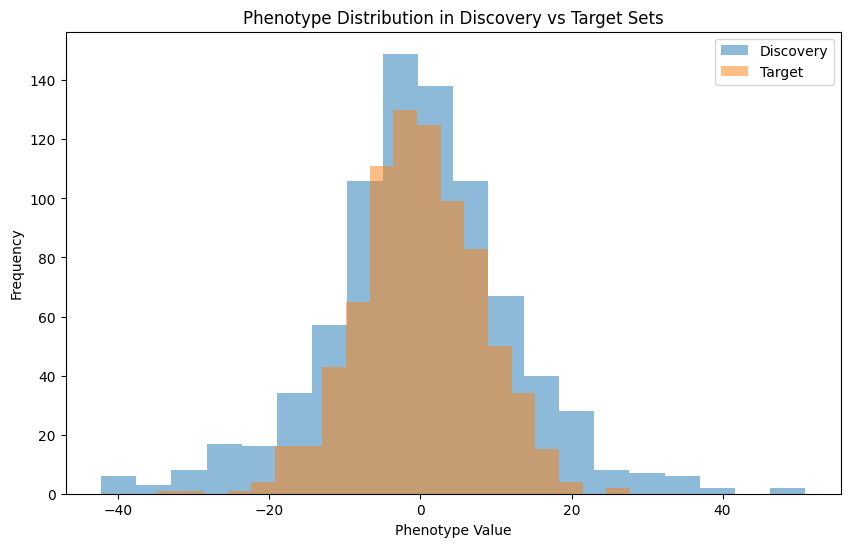

In [30]:
plt.figure(figsize=(10, 6))
plt.hist(train_discovery_pheno, bins=20, alpha=0.5, label='Discovery')
plt.hist(train_target_pheno, bins=20, alpha=0.5, label='Target')
plt.legend()
plt.title('Phenotype Distribution in Discovery vs Target Sets')
plt.xlabel('Phenotype Value')
plt.ylabel('Frequency')
plt.show()


## Step 2: Inspecting the dataloaders

In [37]:
batch_size = 64

In [38]:
input_length = train_discovery.shape[-1]

# ------------------------------------------------------------------
# tensorify
# ------------------------------------------------------------------
training_dataset_torch = torch.tensor(
    train_discovery, dtype=torch.float32
).unsqueeze(1)
validation_dataset_torch = torch.tensor(
    validation_discovery, dtype=torch.float32
).unsqueeze(1)
train_target_dataset_torch = torch.tensor(
    train_target, dtype=torch.float32
).unsqueeze(1)
test_target_dataset_torch = torch.tensor(
    test_target, dtype=torch.float32
).unsqueeze(1)

training_pheno_torch = torch.tensor(train_discovery_pheno, dtype=torch.float32).unsqueeze(
    1
)
validation_pheno_torch = torch.tensor(
    validation_pheno, dtype=torch.float32
).unsqueeze(1)
test_target_pheno_torch = torch.tensor(
    test_target_pheno, dtype=torch.float32
).unsqueeze(1)
train_target_pheno_torch = torch.zeros(
    len(train_target_dataset_torch), 1, dtype=torch.float32
)

In [39]:
val_input_x = validation_dataset_torch
val_mask = torch.zeros(
    validation_dataset_torch.shape[0],
    validation_dataset_torch.shape[2],
    dtype=torch.bool,
)
test_target_input_x = test_target_dataset_torch
test_target_mask = torch.zeros(
    test_target_dataset_torch.shape[0],
    test_target_dataset_torch.shape[2],
    dtype=torch.bool,
)

In [40]:
# ------------------------------------------------------------------
# DataLoaders
# train : (x, pheno, pop_label)          discovery=0, target=1
# val   : (input_x, x, pheno, mask, pop) all pop=0
# test  : (input_x, x, pheno, mask, pop) all pop=1
# ------------------------------------------------------------------
train_ds = TensorDataset(
    torch.cat([training_dataset_torch, train_target_dataset_torch], dim=0),
    torch.cat([training_pheno_torch, train_target_pheno_torch], dim=0),
    torch.cat(
        [
            torch.zeros(len(training_dataset_torch), dtype=torch.long),
            torch.ones(len(train_target_dataset_torch), dtype=torch.long),
        ],
        dim=0,
    ),
)
val_ds = TensorDataset(
    val_input_x,
    validation_dataset_torch,
    validation_pheno_torch,
    val_mask,
    torch.zeros(len(validation_dataset_torch), dtype=torch.long),
)
test_target_ds = TensorDataset(
    test_target_input_x,
    test_target_dataset_torch,
    test_target_pheno_torch,
    test_target_mask,
    torch.ones(len(test_target_dataset_torch), dtype=torch.long),
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_target_loader = DataLoader(
    test_target_ds, batch_size=batch_size, shuffle=False
)


In [41]:
a = next(iter(train_loader))

In [43]:
print(a[0].shape)  # input data
print(a[1].shape)  # phenotype data
print(a[2].shape)  # population label

torch.Size([64, 1, 9013])
torch.Size([64, 1])
torch.Size([64])


In [46]:
print(a[2])
print(f'Proportion of YRI: {(a[2] == 1).float().mean().item():.2f}')

tensor([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0,
        1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
        0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0])
Proportion of YRI: 0.50


## Step 3: Inspect the Model

In [64]:
sys.path.append(str(Path("/sietch_colab/akapoor/XPopVAE")))
from src.model import ConvVAE
from src.loss import recon_masked_loss, recon_unmasked_loss, kl_loss, phenotype_loss

In [55]:
in_channels = 1
hidden_channels = [32, 64, 128, 256, 256, 256]
latent_dim = 512
kernel_size = 17
stride = 2
padding = 8
pheno_hidden_dim = 2
learning_rate = 1e-4

In [56]:
# ------------------------------------------------------------------
# model
# ------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ConvVAE(
    input_length=input_length,
    in_channels=in_channels,
    hidden_channels=hidden_channels,
    kernel_size=kernel_size,
    stride=stride,
    padding=padding,
    latent_dim=latent_dim,
    use_batchnorm=False,
    activation="elu",
    pheno_dim=1,
    pheno_hidden_dim=pheno_hidden_dim,
    num_domains=2,
).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

x_batch = next(iter(train_loader))[0].to(device)
with torch.no_grad():
    logits, mu, logvar, z, pheno_pred, domain_logits = model(x_batch, verbose=True)
print(
    f"logits={logits.shape}  mu={mu.shape}  pheno={pheno_pred.shape}  domain={domain_logits.shape}"
)


Using device: cuda
Parameters: 61405258
Input: torch.Size([64, 1, 9013])
Encoder layer 00 (Conv1d): torch.Size([64, 32, 4507])
Encoder layer 01 (ELU): torch.Size([64, 32, 4507])
Encoder layer 02 (Conv1d): torch.Size([64, 64, 2254])
Encoder layer 03 (ELU): torch.Size([64, 64, 2254])
Encoder layer 04 (Conv1d): torch.Size([64, 128, 1127])
Encoder layer 05 (ELU): torch.Size([64, 128, 1127])
Encoder layer 06 (Conv1d): torch.Size([64, 256, 564])
Encoder layer 07 (ELU): torch.Size([64, 256, 564])
Encoder layer 08 (Conv1d): torch.Size([64, 256, 282])
Encoder layer 09 (ELU): torch.Size([64, 256, 282])
Encoder layer 10 (Conv1d): torch.Size([64, 256, 141])
Encoder layer 11 (ELU): torch.Size([64, 256, 141])
Flattened: torch.Size([64, 36096])
Decoder layer 00 (ConvTranspose1d): torch.Size([64, 256, 282])
Decoder layer 01 (ELU): torch.Size([64, 256, 282])
Decoder layer 02 (ConvTranspose1d): torch.Size([64, 256, 564])
Decoder layer 03 (ELU): torch.Size([64, 256, 564])
Decoder layer 04 (ConvTranspose1

In [57]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [65]:
model.train()

total_loss = 0.0
total_recon_unmasked = 0.0
total_recon_masked = 0.0
total_kl_loss = 0.0
total_phenotype_loss = 0.0
total_domain_loss = 0.0

for x, pheno, pop_label in train_loader:
    x = x.to(device)
    pheno = pheno.to(device)
    pop_label = pop_label.to(device)

    input_x = x
    mask = torch.zeros(
        x.shape[0], x.shape[2], dtype=torch.bool, device=x.device
    )
    input_x = input_x.to(device)
    mask = mask.to(device)

    optimizer.zero_grad()

    logits, mu, logvar, z, pheno_pred, _ = model(input_x)
    targets = x.squeeze(1).long()

    recon_unmasked = recon_unmasked_loss(logits, targets, mask)
    recon_masked = recon_masked_loss(logits, targets, mask)
    kl = kl_loss(mu, logvar)

    # Phenotype supervision on discovery (pop_label == 0) only.
    # Slice to discovery individuals so the MSE mean denominator
    # reflects only supervised samples.
    disc_idx = (pop_label == 0).nonzero(as_tuple=True)[0]
    if disc_idx.numel() > 0:
        pheno_loss_val = phenotype_loss(
            pheno_pred[disc_idx],
            pheno[disc_idx],
        )
    else:
        # edge case: batch contains only target individuals
        pheno_loss_val = torch.tensor(0.0, device=device, requires_grad=True)


In [67]:
print(f'Recon Unmasked: {recon_unmasked.item():.4f}  Recon Masked: {recon_masked.item():.4f}  KL: {kl.item():.4f}  Pheno Loss: {pheno_loss_val.item():.4f}')

Recon Unmasked: 1.1372  Recon Masked: 0.0000  KL: 0.0001  Pheno Loss: 108.1604


### Step 3.1: Gradient Reversal

In [74]:
import torch.nn.functional as F

In [75]:
lambda_grl = 1.0  # You can tune this hyperparameter

In [76]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_grl):
        ctx.save_for_backward(torch.tensor(lambda_grl))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        (lambda_grl,) = ctx.saved_tensors
        return -lambda_grl.item() * grad_output, None


def grad_reverse(x, lambda_grl):
    return GradientReversalFunction.apply(x, lambda_grl)


In [77]:
# Domain adversarial loss via GRL.
# Apply gradient reversal to mu, then pass through domain_head.
# The reversed gradients push the encoder toward population-invariant
# representations while the domain head itself learns to discriminate.

mu_reversed = grad_reverse(mu, lambda_grl)
domain_logits = model.domain_head(mu_reversed)
domain_loss = F.cross_entropy(domain_logits, pop_label)


In [82]:
print(f'Domain Logits Shape: {domain_logits.shape}  Domain Loss: {domain_loss.item():.4f}')

Domain Logits Shape: torch.Size([64, 2])  Domain Loss: 0.6927


In [84]:
print(f'Domain Logits: {domain_logits}')

Domain Logits: tensor([[-0.0531, -0.0143],
        [-0.0523, -0.0090],
        [-0.0514, -0.0130],
        [-0.0510, -0.0157],
        [-0.0516, -0.0105],
        [-0.0535, -0.0175],
        [-0.0505, -0.0137],
        [-0.0472, -0.0134],
        [-0.0504, -0.0120],
        [-0.0512, -0.0101],
        [-0.0518, -0.0163],
        [-0.0503, -0.0142],
        [-0.0504, -0.0066],
        [-0.0492, -0.0125],
        [-0.0480, -0.0103],
        [-0.0514, -0.0093],
        [-0.0508, -0.0094],
        [-0.0509, -0.0122],
        [-0.0545, -0.0113],
        [-0.0485, -0.0096],
        [-0.0510, -0.0099],
        [-0.0510, -0.0165],
        [-0.0491, -0.0096],
        [-0.0518, -0.0124],
        [-0.0515, -0.0170],
        [-0.0535, -0.0122],
        [-0.0477, -0.0124],
        [-0.0489, -0.0100],
        [-0.0475, -0.0112],
        [-0.0486, -0.0149],
        [-0.0487, -0.0082],
        [-0.0477, -0.0109],
        [-0.0500, -0.0097],
        [-0.0507, -0.0096],
        [-0.0509, -0.0137],
     